Siêu thị đặt mục tiêu dự đoán khả năng một khách hàng sẽ đưa ra phản hồi tích cực, đồng thời xác định những yếu tố ảnh hưởng đến quyết định này. Nhiệm vụ của chúng ta là phân tích tập dữ liệu hiện có để tìm ra các yếu tố then chốt, và từ đó xây dựng một mô hình dự báo có thể ước tính xác suất khách hàng phản hồi tích cực trong tương lai.

| Biến                   | Mô tả                                                     | Kiểu dữ liệu |
|------------------------|------------------------------------------------------------|---------------|
| `Year_Birth`           | Năm sinh của khách hàng                                    | int64         |
| `Education`            | Trình độ học vấn của khách hàng                            | object        |
| `Marital_Status`       | Tình trạng hôn nhân của khách hàng                         | object        |
| `Income`               | Thu nhập hàng năm của hộ gia đình                          | float64       |
| `Kidhome`              | Số trẻ em sống cùng khách hàng                             | int64         |
| `Teenhome`             | Số thiếu niên sống cùng khách hàng                         | int64         |
| `Recency`              | Số ngày kể từ lần mua hàng gần nhất                        | int64         |
| `MntWines`             | Chi tiêu cho rượu vang trong 2 năm qua                     | int64         |
| `MntFruits`            | Chi tiêu cho trái cây trong 2 năm qua                      | int64         |
| `MntMeatProducts`      | Chi tiêu cho thịt trong 2 năm qua                          | int64         |
| `MntFishProducts`      | Chi tiêu cho cá trong 2 năm qua                            | int64         |
| `MntSweetProducts`     | Chi tiêu cho đồ ngọt trong 2 năm qua                       | int64         |
| `MntGoldProds`         | Chi tiêu cho sản phẩm vàng trong 2 năm qua                 | int64         |
| `NumDealsPurchases`    | Số lần mua hàng trong chương trình khuyến mãi             | int64         |
| `NumWebPurchases`      | Số lần mua hàng qua trang web                              | int64         |
| `NumCatalogPurchases`  | Số lần mua hàng qua catalog                                | int64         |
| `NumStorePurchases`    | Số lần mua hàng trực tiếp tại cửa hàng                     | int64         |
| `NumWebVisitsMonth`    | Số lần truy cập trang web trong tháng qua                  | int64         |


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("D:/NMMH/Clustered_Customer_Data/marketing_campaign.csv")

In [ ]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,1957,Graduation,Single,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7
1,1954,Graduation,Single,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5
2,1965,Graduation,Together,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4
3,1984,Graduation,Together,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6
4,1981,PhD,Married,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5


In [ ]:
df.tail()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
2211,1967,Graduation,Married,61223.0,0,1,46,709,43,182,42,118,247,2,9,3,4,5
2212,1946,PhD,Together,64014.0,2,1,56,406,0,30,0,0,8,7,8,2,5,7
2213,1981,Graduation,Divorced,56981.0,0,0,91,908,48,217,32,12,24,1,2,3,13,6
2214,1956,Master,Together,69245.0,0,1,8,428,30,214,80,30,61,2,6,5,10,3
2215,1954,PhD,Married,52869.0,1,1,40,84,3,61,2,1,21,3,3,1,4,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2216 entries, 0 to 2215
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2216 non-null   int64  
 1   Education            2216 non-null   object 
 2   Marital_Status       2216 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2216 non-null   int64  
 5   Teenhome             2216 non-null   int64  
 6   Recency              2216 non-null   int64  
 7   MntWines             2216 non-null   int64  
 8   MntFruits            2216 non-null   int64  
 9   MntMeatProducts      2216 non-null   int64  
 10  MntFishProducts      2216 non-null   int64  
 11  MntSweetProducts     2216 non-null   int64  
 12  MntGoldProds         2216 non-null   int64  
 13  NumDealsPurchases    2216 non-null   int64  
 14  NumWebPurchases      2216 non-null   int64  
 15  NumCatalogPurchases  2216 non-null   i

In [ ]:
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,2.323556,4.085289,2.671029,5.800993,5.319043
std,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,1.923716,2.740951,2.926734,3.250785,2.425359
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,2.000000,4.000000,2.000000,5.000000,6.000000
75%,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,15.000000,27.000000,28.000000,13.000000,20.000000


#Exploratory Data Analysis

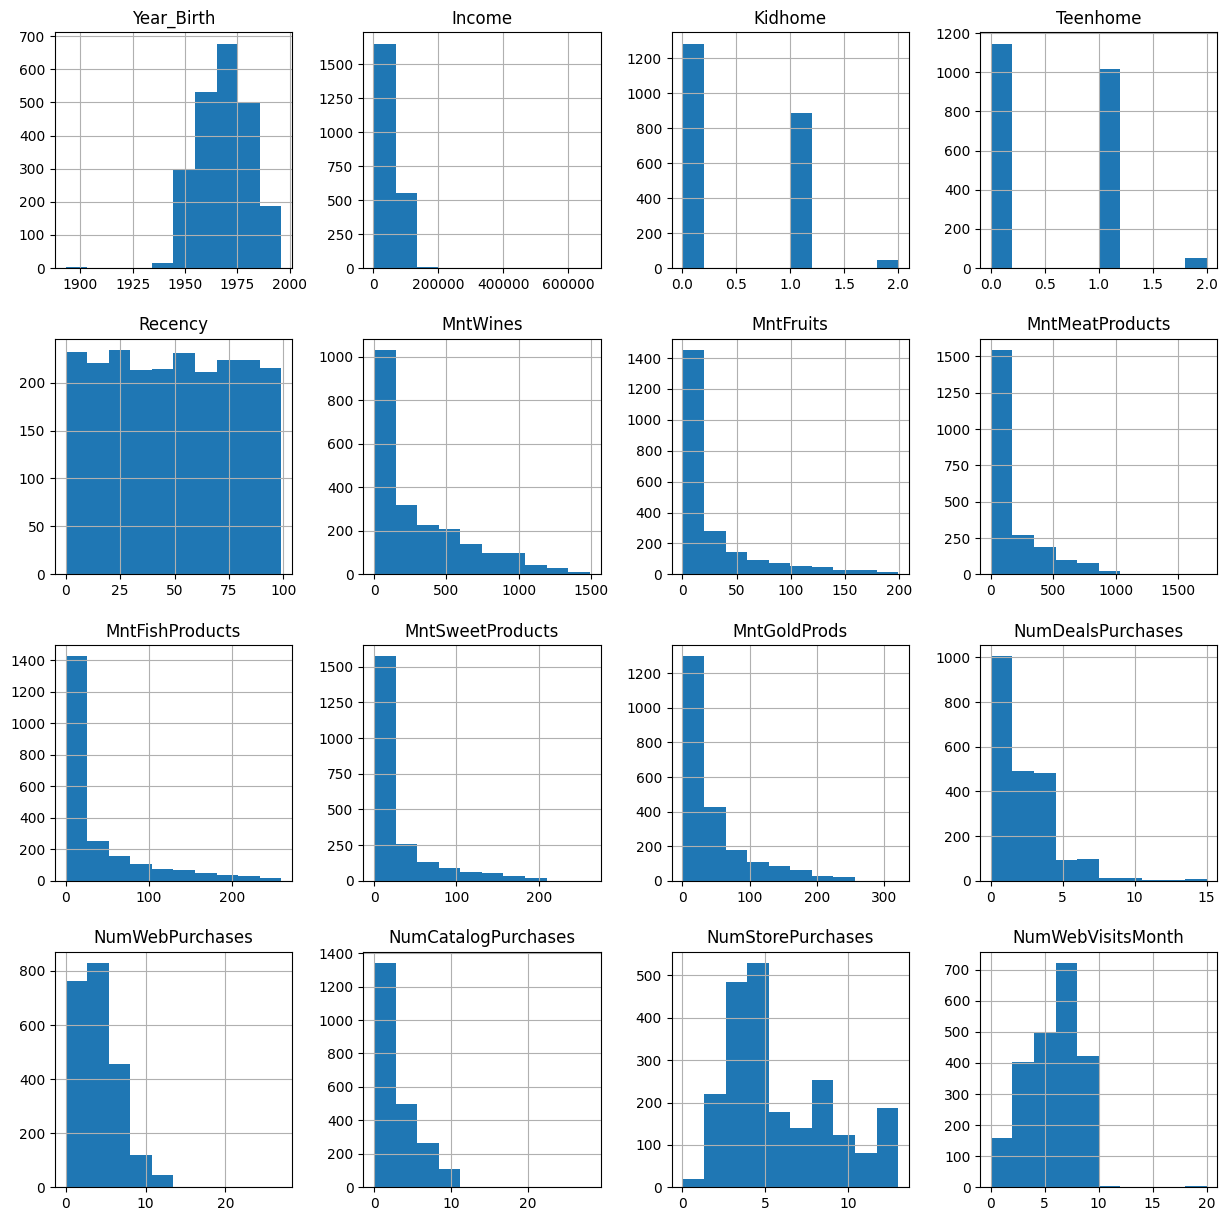

In [ ]:
df.hist(figsize=(15, 15))
plt.show()

In [ ]:
cat_cols = [col for col in df.columns if df[col].dtypes=="O"] # với mỗi col trong df.columns sao cho df[col].dtypes là "O" (dạng Object) thì ta đưa col vào list

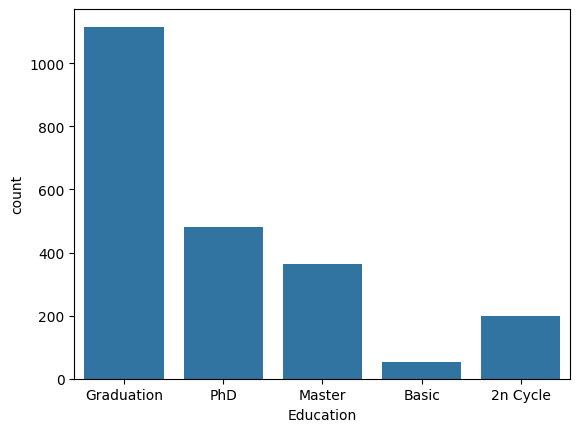

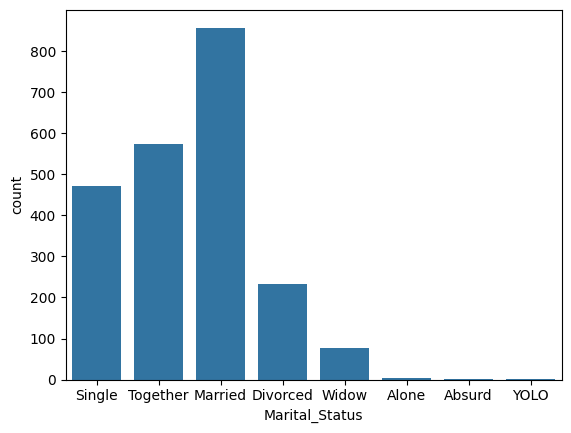

In [ ]:
for col in cat_cols: #Với mỗi phần tử col có trong cat_cols
    sns.countplot(x=col, data=df) #ta vẽ hình dạng countplot cho từng col
    plt.show() #phải dùng nếu không thì chỉ vẽ hình cuối cùng trong list

#Data Preprocessing

In [ ]:
data = df.copy()

In [ ]:
data.loc[:, "Education"] = data["Education"].replace("2n Cycle", "Master")
data.loc[:, "Education"] = data["Education"].apply(lambda x: 0 if x=="Basic" else 1 if x=="Graduation" else 2 if x=="Master" else 3)
data = pd.get_dummies(data, columns=["Marital_Status"], dtype=int)
data.head()

,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumStorePurchases,NumWebVisitsMonth,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,1957,1,58138.0,0,0,58,635,88,546,172,...,4,7,0,0,0,0,1,0,0,0
1,1954,1,46344.0,1,1,38,11,1,6,2,...,2,5,0,0,0,0,1,0,0,0
2,1965,1,71613.0,0,0,26,426,49,127,111,...,10,4,0,0,0,0,0,1,0,0
3,1984,1,26646.0,1,0,26,11,4,20,10,...,4,6,0,0,0,0,0,1,0,0
4,1981,3,58293.0,1,0,94,173,43,118,46,...,6,5,0,0,0,1,0,0,0,0


In [ ]:
df.Marital_Status.value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data.values)

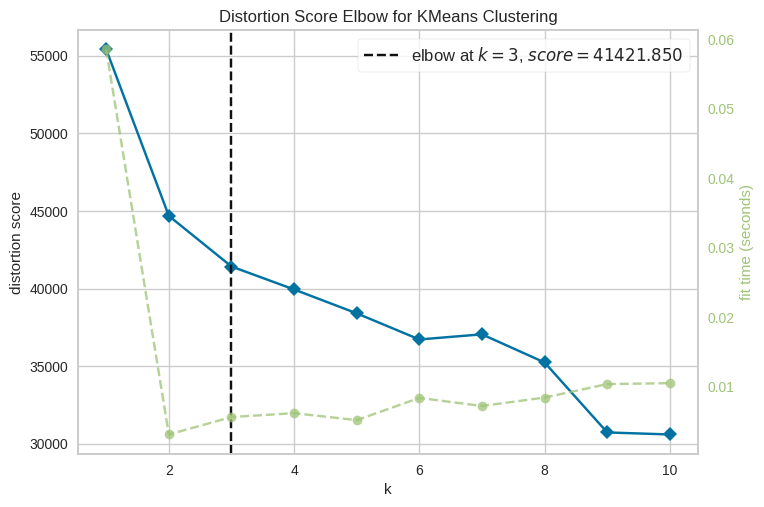

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
elbow_method = KElbowVisualizer(KMeans(), k=(1,11))
elbow_method.fit(scaled_data)
elbow_method.show()

In [ ]:
kmeans_model = KMeans(n_clusters=3)
kmeans_model.fit(scaled_data)

KMeans(n_clusters=3)

In [ ]:
#để xuất ra label của tập training (scaled_data) ta dùng .labels_
kmeans_model.labels_

array([2, 1, 2, ..., 0, 0, 1], dtype=int32)

In [ ]:
#để dự đoán ra label của tập testing (ta giả sử là scaled_data) ta dùng .predict
kmeans_model.predict(scaled_data)

array([1, 2, 1, ..., 0, 0, 2], dtype=int32)

In [ ]:
#Để xuất ra các centroids ta có thể dùng .cluster_centers_
kmeans_model.cluster_centers_

array([[-3.60153506e-01,  1.94464730e-01,  2.29650600e-01,
        -3.96963989e-01,  7.67009132e-01, -1.64591511e-02,
         4.76480430e-01, -1.45725689e-01, -1.47748360e-01,
        -1.75918833e-01, -1.41827560e-01,  2.88733313e-01,
         6.96976426e-01,  7.81598758e-01,  1.17278919e-01,
         5.55279080e-01,  1.63742645e-01, -3.00556545e-02,
         6.07839692e-03,  8.04957878e-02,  8.03583732e-02,
        -1.72544215e-01, -1.05761769e-02,  5.42232581e-02,
         7.49969170e-02],
       [-4.36735194e-02, -4.29023211e-02,  9.76958639e-01,
        -7.45817452e-01, -6.08347315e-01,  1.14388334e-02,
         8.44604804e-01,  1.09526047e+00,  1.27802082e+00,
         1.15698428e+00,  1.08659936e+00,  6.43391689e-01,
        -5.14860981e-01,  4.11947643e-01,  1.14123386e+00,
         7.98831667e-01, -1.02903231e+00,  8.49760041e-02,
        -3.68188246e-02, -4.86126186e-02, -7.41853043e-02,
         9.26078544e-02,  1.29603394e-02,  3.93142898e-02,
        -3.00556545e-02],
    

##PCA

In [ ]:
from sklearn.decomposition import PCA #Khai báo thư viện PCA
pca = PCA(n_components=3) #khai báo
pca.fit(scaled_data)

PCA(n_components=3)

In [ ]:
#cho ta biết được các thành phần phủ được bao nhiêu lượng thông tin của data gốc
a = pca.explained_variance_ratio_ * 100

In [ ]:
a

array([24.38626095,  8.24365241,  6.05396014])

##3 dimensional PCA

In [ ]:
pca = PCA(n_components=3) #dùng pca 3 thành phần
pca_df = pd.DataFrame(pca.fit_transform(scaled_data), columns=["pca_1", "pca_2", "pca_3"])#tạo ra dataframe với 3 thành phàn là pca1, pca2, và pca3

In [ ]:
pca_ = PCA(n_components=3)
pca_.fit(scaled_data)
pca_.explained_variance_ratio_

array([0.24386261, 0.08243652, 0.0605396 ])

In [ ]:
pca_df

,pca_1,pca_2,pca_3
0,3.809293,-0.818080,-0.509260
1,-2.307326,-0.327860,-0.987788
2,1.885919,-0.224688,-1.281190
3,-2.475711,-1.388924,-1.123704
4,-0.286474,0.026921,1.668202
...,...,...,...
2211,2.666305,1.014460,1.690400
2212,-1.521844,3.435210,-1.365196
2213,1.309219,-0.524455,-0.446439
2214,2.061956,1.269482,-1.462697


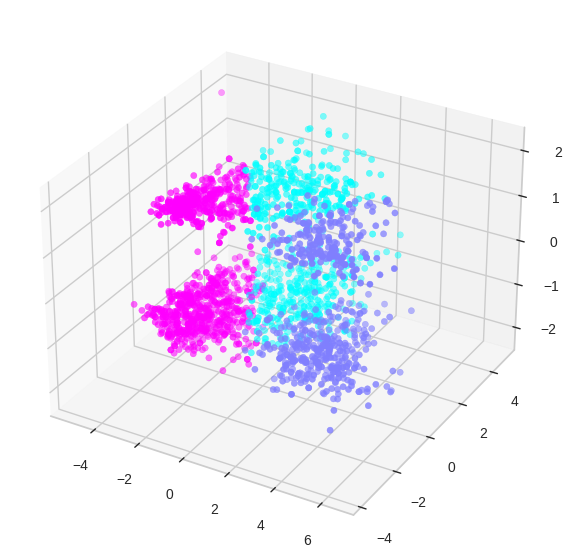

In [ ]:
plt.figure(figsize=(12, 7))
ax = plt.subplot(projection="3d")
ax.scatter(pca_df.pca_1, pca_df.pca_2, pca_df.pca_3, c=kmeans_model.labels_, cmap="cool")
plt.show()

##2 dimensional PCA

In [ ]:
pca = PCA(n_components=2)
pca.fit(scaled_data)
pca_df = pd.DataFrame(pca.transform(scaled_data), columns=["pca1", "pca2"])

In [ ]:
pca.components_


array([[-0.06729317,  0.01212828,  0.30255411, -0.27162504, -0.04778199,
         0.00587296,  0.30456886,  0.28523898,  0.32474402,  0.29505818,
         0.28486409,  0.23503428, -0.05094077,  0.22400931,  0.33090817,
         0.30251757, -0.26330158,  0.02236158, -0.01252447,  0.00185396,
        -0.01016178, -0.00311532,  0.00149441,  0.02714882, -0.00500776],
       [-0.35825179,  0.21655496,  0.06482079, -0.06990245,  0.52062351,
        -0.0017145 ,  0.18207386, -0.14579698, -0.13482995, -0.15729928,
        -0.12638001,  0.06374889,  0.43158666,  0.33550289,  0.00891167,
         0.15816309,  0.18527992, -0.044101  ,  0.0226261 ,  0.09771977,
         0.02464856, -0.20078891,  0.04757705,  0.09874793,  0.06369268]])

In [ ]:
pca_df.head()

,pca1,pca2
0,3.809293,-0.818080
1,-2.307326,-0.327860
2,1.885919,-0.224688
3,-2.475711,-1.388924
4,-0.286474,0.026921


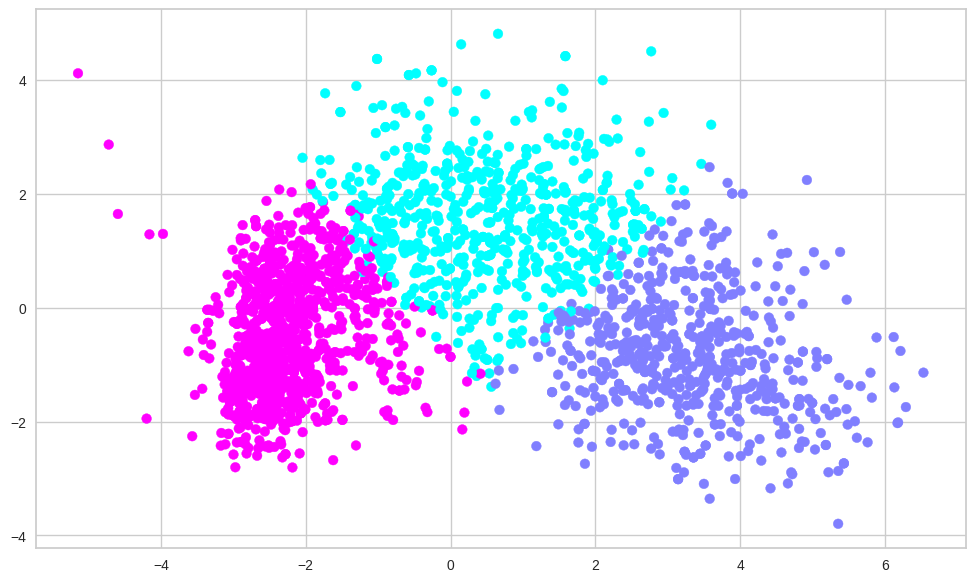

In [ ]:
plt.figure(figsize=(12, 7))
ax = plt.subplot()
ax.scatter(pca_df.pca1, pca_df.pca2, c=kmeans_model.labels_, cmap="cool")
plt.show()

##Nếu muốn vẽ có thêm legend

<ipython-input-31-acdd45d4ed8d>:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(pca_df.iloc[index].pca1, pca_df.iloc[index].pca2, label=g, cmap="cool")


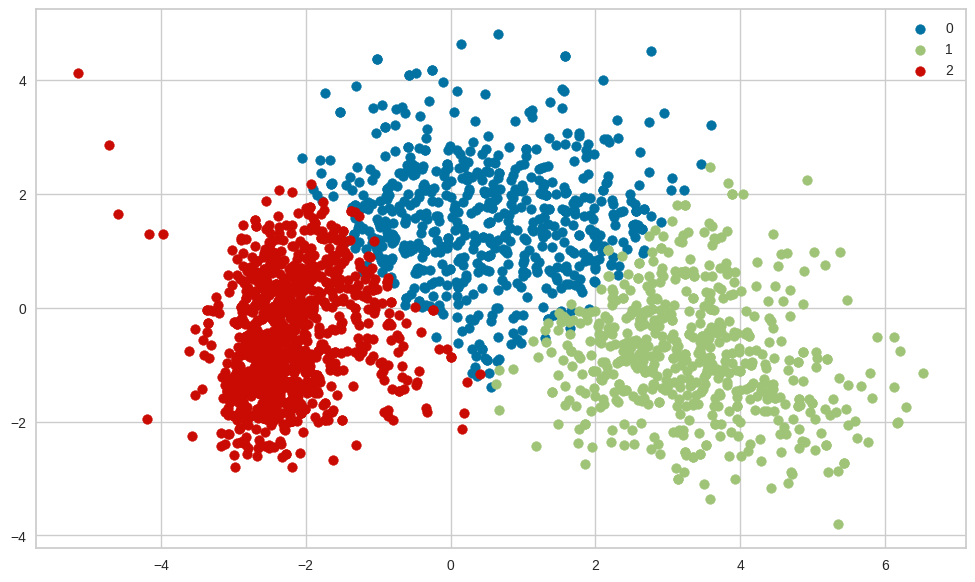

In [ ]:
plt.figure(figsize=(12, 7))
ax = plt.subplot()
group = kmeans_model.labels_
for g in np.unique(group):
    index = np.where(group==g)
    ax.scatter(pca_df.iloc[index].pca1, pca_df.iloc[index].pca2, label=g, cmap="cool")
ax.legend()
plt.show()

#Save và load model

In [ ]:
#Save model
import pickle #import thư viện pickle

file_name = "model.sav" #Tạo tên cũng như đường dẫn lưu model (nếu chỉ để tên model không thì sẽ lưu tại thư mục hiện hành)
pickle.dump(kmeans_model, open(file_name, "wb")) #nhận vào tên thư viện và đường dẫn lưu trữ model

file_name = "scaler.sav" #Tạo tên cũng như đường dẫn lưu model (nếu chỉ để tên model không thì sẽ lưu tại thư mục hiện hành)
pickle.dump(scaler, open(file_name, "wb")) #nhận vào tên thư viện và đường dẫn lưu trữ model

In [ ]:
#Load model
file_name = "model.sav"
model = pickle.load(open(file_name, "rb"))

file_name = "scaler.sav"
scaler = pickle.load(open(file_name, "rb"))

#Lấy ra các dataframe theo cluster

In [ ]:
model.labels_

array([1, 2, 1, ..., 0, 0, 2], dtype=int32)

In [ ]:
cluster = model.labels_
cluster_0 = np.where(cluster==0) #index các data samples thuộc cluster 1
cluster_1 = np.where(cluster==1) #index các data samples thuộc cluster 2
cluster_2 = np.where(cluster==2) #index các data samples thuộc cluster 3

In [ ]:
#Lấy ra các data samples thuộc cluster 1
data.iloc[cluster_0]

,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumStorePurchases,NumWebVisitsMonth,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
4,1981,3,58293.0,1,0,94,173,43,118,46,...,6,5,0,0,0,1,0,0,0,0
5,1967,2,62513.0,0,1,16,520,42,98,0,...,10,6,0,0,0,0,0,1,0,0
6,1971,1,55635.0,0,1,34,235,65,164,50,...,7,6,0,0,1,0,0,0,0,0
12,1952,2,59354.0,1,1,53,233,2,53,3,...,5,6,0,0,1,0,0,0,0,0
17,1949,2,76995.0,0,1,91,1012,80,498,0,...,9,5,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2207,1970,2,44802.0,0,0,71,853,10,143,13,...,12,8,0,0,0,0,1,0,0,0
2211,1967,1,61223.0,0,1,46,709,43,182,42,...,4,5,0,0,0,1,0,0,0,0
2212,1946,3,64014.0,2,1,56,406,0,30,0,...,5,7,0,0,0,0,0,1,0,0
2213,1981,1,56981.0,0,0,91,908,48,217,32,...,13,6,0,0,1,0,0,0,0,0
